## Testing fucntions

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import gstools as gs
# import matplotlib.pyplot as plt
# import matplotlib.tri as tri
# import plotly.graph_objects as go
# from gstools.random import MasterRNG
# from plotly.subplots import make_subplots
# from utilies import *

### Sampling fucntion for CRF generation

In [9]:
# Sythetic dataframe
df = pd.DataFrame(
    {'X': [1, 2, 3, 4],
     'Y': [10, 20, 30, 40],
     'Z': [100, 200, 300, 400],
     'logK': [0.1, 0.2, 0.3, 0.4]}, 
    index = ['node_1', 'node_2', 'node_3', 'node_4'])
print(df)

        X   Y    Z  logK
node_1  1  10  100   0.1
node_2  2  20  200   0.2
node_3  3  30  300   0.3
node_4  4  40  400   0.4


In [31]:
# Using "sample" method 
sampling_result = df['logK'].sample(n = 1)
print(sampling_result)

node_3    0.3
Name: logK, dtype: float64


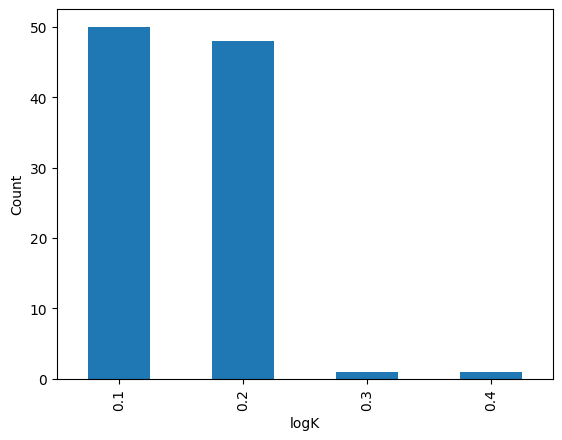

In [62]:
#  Add weight to sampling method
df['weight'] = [10, 10, 0.1, 0.1]

value = []
for i in range(100):
    sampling_result = df['logK'].sample(n = 1, weights = df['weight'])
    value.append(sampling_result.iloc[0])

result = pd.Series(value)
count = result.value_counts().sort_index()
count.plot(kind="bar")
plt.xlabel("logK")
plt.ylabel("Count")
plt.show()

In [115]:
# Using groupby method in sampling

df['X_section'] = (df['X'] // 2.5).astype(int) 
df['Y_section'] = (df['Y'] //  25).astype(int) 
df['Z_section'] = (df['Z'] // 250).astype(int) 

group = df.groupby(['X_section', 'Y_section', 'Z_section'])

# Separate the domain into 4 section
print(group.groups.keys())

for name, data in group:
    print("Group:", name)
    print(data)
    print("-"*70)

dict_keys([(0, 0, 0), (1, 1, 1)])
Group: (np.int64(0), np.int64(0), np.int64(0))
        X   Y    Z  logK  weight  X_section  Y_section  Z_section
node_1  1  10  100   0.1    10.0          0          0          0
node_2  2  20  200   0.2    10.0          0          0          0
----------------------------------------------------------------------
Group: (np.int64(1), np.int64(1), np.int64(1))
        X   Y    Z  logK  weight  X_section  Y_section  Z_section
node_3  3  30  300   0.3     0.1          1          1          1
node_4  4  40  400   0.4     0.1          1          1          1
----------------------------------------------------------------------


In [121]:
group = df.groupby(
    ["X_section", "Y_section", "Z_section"]
).sample(frac= 0.5)

group

,X,Y,Z,logK,weight,X_section,Y_section,Z_section
node_1,1,10,100,0.1,10.0,0,0,0
node_3,3,30,300,0.3,0.1,1,1,1


In [111]:
# Calculate the weight based on the distance
df_j = pd.DataFrame(
    {
     'name': ['w1', 'w2'],
    'X': [0, 100],
    'Y': [0, 100],
    'Z': [0, 100],   
    }
)

points = df[['X', 'Y', 'Z']].to_numpy()      # (node, 3)
wells = df_j[['X', 'Y', 'Z']].to_numpy()      # (well, 3)

dist = np.linalg.norm(
    points[:, None, :] - wells[None, :, :],  # Broadcasting (node, 1, 3) : (1, well, 3)
    axis=2
)

print(dist)
sigma = 10**4
weight = 1/(dist**2).sum(axis = 1)*sigma
print(weight.T)

[[100.50373127 133.79461873]
 [201.00746255 161.25755796]
 [301.51119382 233.0429145 ]
 [402.0149251  320.64934118]]
[0.35711735 0.15058427 0.06886199 0.03781691]


In [ ]:
df['weight'] = weight

